# Beyond Churn: Causal Uplift Modeling

This notebook explores a simple question:

> **Are the customers most likely to churn also the customers that are most likely to benefit from a targeted retention treatment?**

I will compare a predictive churn-risk model with three causal treatment-effect approaches:

- T-Learner
- DRLearner
- CausalForestDML

My goal here is not to find the most complicated model. The goal is to compare targeting decisions on a held-out randomized experiment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openml

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

from catboost import CatBoostClassifier
from xgboost import XGBClassifier, XGBRegressor
from econml.dr import DRLearner
from econml.dml import CausalForestDML

RANDOM_STATE = 42

## 1. Load and prepare the data

The dataset contains customer features, a randomized treatment indicator (`t`), and our churn outcome (`y`).

`y = 1` means the customer churned. And note that a positive **retention uplift** means treatment reduced churn.

In [2]:
dataset = openml.datasets.get_dataset(45580)

X_raw, y, _, _ = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

df = X_raw.copy()
df["y"] = y

treatment = df["t"].astype(int)
y = df["y"].astype(int)

X = df.drop(columns=["t", "y"]).copy()

# FACTOR3 is constant and provides no modeling information.
if "FACTOR3" in X.columns:
    X = X.drop(columns=["FACTOR3"])

categorical_cols = X.select_dtypes(
    include=["object", "string", "str", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

X[categorical_cols] = X[categorical_cols].astype(str)

print("Rows:", len(X))
print("Features:", X.shape[1])
print("Treatment rate:", treatment.mean().round(4))
print("Churn rate:", y.mean().round(4))

Rows: 11896
Features: 177
Treatment rate: 0.7574
Churn rate: 0.0343


## 2. Check the average treatment effect

Note that because the treatment was randomized the overall difference in churn between treatment and control should give us a simple experimental baseline.

In [3]:
control_churn = y[treatment == 0].mean()
treatment_churn = y[treatment == 1].mean()
overall_retention_uplift = control_churn - treatment_churn

print(f"Control churn rate:   {control_churn:.4f}")
print(f"Treatment churn rate: {treatment_churn:.4f}")
print(f"Retention uplift:     {overall_retention_uplift:.4f}")

Control churn rate:   0.0364
Treatment churn rate: 0.0336
Retention uplift:     0.0028


The average treatment effect is small. That does not mean treatment is equally useful for every customer. The rest of the notebook looks for differences in treatment response.

## 3. Create a hold-out causal evaluation set

All models will use the same training and evaluation split so the targeting comparison is fair

In [4]:
causal_strata = treatment.astype(str) + "_" + y.astype(str)

train_idx, eval_idx = train_test_split(
    X.index,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=causal_strata
)

X_causal_train = X.loc[train_idx].copy()
X_causal_eval = X.loc[eval_idx].copy()

y_causal_train = y.loc[train_idx].copy()
y_causal_eval = y.loc[eval_idx].copy()

treatment_train = treatment.loc[train_idx].copy()
treatment_eval = treatment.loc[eval_idx].copy()

eval_results = pd.DataFrame({
    "y": y_causal_eval,
    "treatment": treatment_eval
})

print("Training rows:", len(X_causal_train))
print("Evaluation rows:", len(X_causal_eval))

Training rows: 8922
Evaluation rows: 2974


## 4. Predictive baseline: churn risk

The predictive model answers:

> **Who is most likely to churn without intervention?**

I will reuse the CatBoost settings selected in the churn-prediction notebook. But I will refit the model only on control customers from this training split. This should keep the held-out policy comparison fair.

In [5]:
risk_model = CatBoostClassifier(
    depth=6,
    iterations=300,
    learning_rate=0.03,
    l2_leaf_reg=10,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=0
)

X_risk_train = X_causal_train.loc[treatment_train == 0].copy()
y_risk_train = y_causal_train.loc[treatment_train == 0].copy()

X_risk_train[categorical_cols] = X_risk_train[categorical_cols].astype(str)

risk_model.fit(
    X_risk_train,
    y_risk_train,
    cat_features=categorical_cols
)

X_causal_eval_catboost = X_causal_eval.copy()
X_causal_eval_catboost[categorical_cols] = (
    X_causal_eval_catboost[categorical_cols].astype(str)
)

eval_results["predicted_churn_risk"] = risk_model.predict_proba(
    X_causal_eval_catboost
)[:, 1]

In [6]:
# summary of predicted churn risk model score
pd.Series(
    eval_results["predicted_churn_risk"],
    name="Predicted churn risk score"
).describe()

count    2974.000000
mean        0.025860
std         0.029468
min         0.001898
25%         0.006988
50%         0.013251
75%         0.034831
max         0.268299
Name: Predicted churn risk score, dtype: float64

In [7]:
# quick eval using avg precision and ROC AUC
control_eval_mask = treatment_eval == 0

control_eval_predictions = eval_results.loc[
    control_eval_mask,
    "predicted_churn_risk"
]

control_eval_y = y_causal_eval.loc[control_eval_mask]

print(
    "ROC AUC:",
    roc_auc_score(
        control_eval_y,
        control_eval_predictions
    )
)

print(
    "Average precision:",
    average_precision_score(
        control_eval_y,
        control_eval_predictions
    )
)

ROC AUC: 0.8931377974543442
Average precision: 0.2147477133988203


The CatBoost model assigns generally low churn-risk scores, with a smaller high-risk tail. But because the model is not calibrated these values are used for ranking customers rather than as literal churn probabilities

## 5. T-Learner baseline

A T-Learner fits separate outcome models for treatment and control. And the difference between their predicted churn probabilities becomes the estimated retention uplift.

In [8]:
causal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

control_model = Pipeline([
    ("preprocess", clone(causal_preprocessor)),
    (
        "model",
        CalibratedClassifierCV(
            LogisticRegression(max_iter=2000),
            method="sigmoid",
            cv=5
        )
    )
])

treatment_model = Pipeline([
    ("preprocess", clone(causal_preprocessor)),
    (
        "model",
        CalibratedClassifierCV(
            LogisticRegression(max_iter=2000),
            method="sigmoid",
            cv=5
        )
    )
])

control_model.fit(
    X_causal_train.loc[treatment_train == 0],
    y_causal_train.loc[treatment_train == 0]
)

treatment_model.fit(
    X_causal_train.loc[treatment_train == 1],
    y_causal_train.loc[treatment_train == 1]
)

pred_control = control_model.predict_proba(X_causal_eval)[:, 1]
pred_treatment = treatment_model.predict_proba(X_causal_eval)[:, 1]

eval_results["predicted_t_uplift"] = pred_control - pred_treatment

In [9]:
pd.Series(
    eval_results["predicted_t_uplift"],
    name="T-Learner retention uplift"
).describe()

count    2974.000000
mean        0.004727
std         0.037722
min        -0.556440
25%        -0.005122
50%         0.006864
75%         0.018028
max         0.531541
Name: T-Learner retention uplift, dtype: float64

The T-Learner predicts moderate average retention uplift, with most cusers clustered around zero but there's some extreme treatment-effect estimates in the tails

## 6. Prepare numeric features for EconML

The following causal models need numeric inputs. I'm going to fit a preprocessing step on the training data and reuse it for evaluation.

In [10]:
causal_numeric_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

X_causal_train_numeric = causal_numeric_preprocessor.fit_transform(
    X_causal_train
)

X_causal_eval_numeric = causal_numeric_preprocessor.transform(
    X_causal_eval
)

print("Training matrix:", X_causal_train_numeric.shape)
print("Evaluation matrix:", X_causal_eval_numeric.shape)

Training matrix: (8922, 335)
Evaluation matrix: (2974, 335)


## 7. DRLearner

DRLearner combines outcome modeling with treatment propensity to estimate customer-level treatment effects.

Note that because treatment was randomized, the propensity model only needs the overall treatment rate. XGBoost will be used for the outcome and final treatment-effect models.

In [11]:
dr_learner = DRLearner(
    model_propensity=DummyClassifier(strategy="prior"),
    model_regression=XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    model_final=XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    discrete_outcome=True,
    cv=5,
    random_state=RANDOM_STATE
)

dr_learner.fit(
    np.asarray(y_causal_train).ravel(),
    np.asarray(treatment_train).ravel(),
    X=X_causal_train_numeric
)

dr_effect = np.asarray(
    dr_learner.effect(
        X_causal_eval_numeric,
        T0=0,
        T1=1
    )
).ravel()

eval_results["predicted_dr_uplift"] = -dr_effect

pd.Series(
    eval_results["predicted_dr_uplift"],
    name="DRLearner retention uplift"
).describe()

count    2974.000000
mean        0.004089
std         0.059115
min        -0.383656
25%        -0.021580
50%        -0.003174
75%         0.017841
max         0.770833
Name: DRLearner retention uplift, dtype: float64

DRLearner predicts substantial treatment-effect heterogeneity. Most customers have effects near zero while a smaller subset is predicted to receive larger retention benefits.

## 8. CausalForestDML

CausalForestDML uses double machine learning and a causal forest to estimate treatment-effect heterogeneity

In [12]:
causal_forest = CausalForestDML(
    model_y=XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    model_t=DummyClassifier(strategy="prior"),
    discrete_outcome=True,
    discrete_treatment=True,
    n_estimators=500,
    min_samples_leaf=20,
    honest=True,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

causal_forest.fit(
    np.asarray(y_causal_train).ravel(),
    np.asarray(treatment_train).ravel(),
    X=X_causal_train_numeric
)

cf_effect = np.asarray(
    causal_forest.effect(
        X_causal_eval_numeric,
        T0=0,
        T1=1
    )
).ravel()

eval_results["predicted_cf_uplift"] = -cf_effect

pd.Series(
    eval_results["predicted_cf_uplift"],
    name="CausalForestDML retention uplift"
).describe()

count    2974.000000
mean        0.001758
std         0.005089
min        -0.018491
25%        -0.001054
50%         0.001428
75%         0.004154
max         0.026787
Name: CausalForestDML retention uplift, dtype: float64

CausalForestDML produces more conservative treatment-effect estimates than DRLearner, with most predicted uplift values clustered around zero and relatively little variation across customers

## 9. Compare targeting policies

Main decision question:

> **If we can only intervene on a limited share of customers, which ranking should we use?**

For each model we target the highest-ranked customers and measure the observed treatment-control churn difference inside that selected group.

In [13]:
policy_budgets = [0.05, 0.10, 0.20, 0.30, 0.50]

policy_columns = {
    "Churn risk": "predicted_churn_risk",
    "T-Learner": "predicted_t_uplift",
    "DRLearner": "predicted_dr_uplift",
    "CausalForestDML": "predicted_cf_uplift"
}

policy_rows = []

for fraction in policy_budgets:
    n_target = int(len(eval_results) * fraction)

    row = {
        "Targeting fraction": fraction,
        "Customers targeted": n_target
    }

    for policy_name, score_col in policy_columns.items():
        targeted = eval_results.nlargest(n_target, score_col)

        control_rate = targeted.loc[
            targeted["treatment"] == 0,
            "y"
        ].mean()

        treatment_rate = targeted.loc[
            targeted["treatment"] == 1,
            "y"
        ].mean()

        row[policy_name] = control_rate - treatment_rate

    random_uplifts = []

    for seed in range(250):
        targeted = eval_results.sample(
            n=n_target,
            random_state=seed
        )

        control_rate = targeted.loc[
            targeted["treatment"] == 0,
            "y"
        ].mean()

        treatment_rate = targeted.loc[
            targeted["treatment"] == 1,
            "y"
        ].mean()

        random_uplifts.append(control_rate - treatment_rate)

    row["Random"] = np.nanmean(random_uplifts)
    policy_rows.append(row)

policy_comparison = pd.DataFrame(policy_rows)

policy_comparison

,Targeting fraction,Customers targeted,Churn risk,T-Learner,DRLearner,CausalForestDML,Random
0,0.05,148,0.133249,0.035352,0.041466,-0.038978,0.003507
1,0.10,297,0.105446,0.017917,-0.005045,-0.028984,0.003708
2,0.20,594,0.021243,0.007778,0.014223,-0.008547,0.003187
3,0.30,892,0.045502,0.005100,0.014459,-0.002809,0.003610
4,0.50,1487,0.018861,0.003682,0.007502,0.001610,0.003499


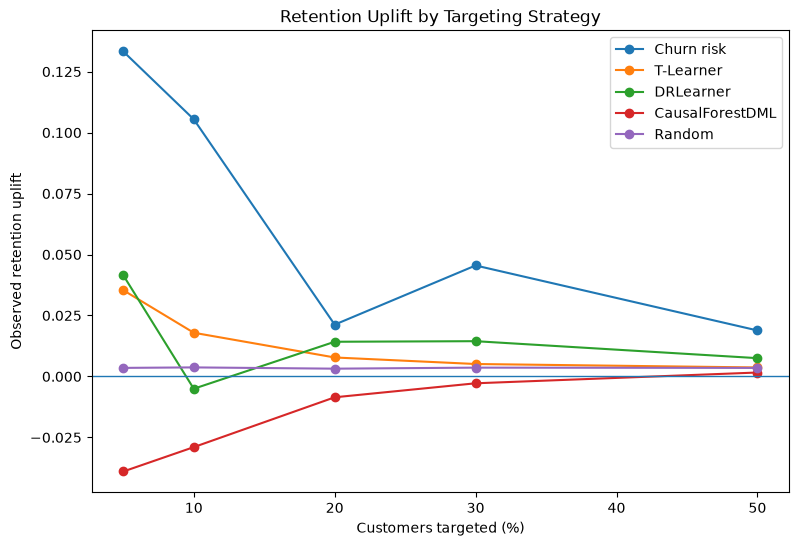

In [14]:
policy_plot = policy_comparison.copy()
policy_plot["Customers targeted (%)"] = (
    policy_plot["Targeting fraction"] * 100
)

plt.figure(figsize=(9, 6))

for policy in [
    "Churn risk",
    "T-Learner",
    "DRLearner",
    "CausalForestDML",
    "Random"
]:
    plt.plot(
        policy_plot["Customers targeted (%)"],
        policy_plot[policy],
        marker="o",
        label=policy
    )

plt.axhline(0, linewidth=1)
plt.xlabel("Customers targeted (%)")
plt.ylabel("Observed retention uplift")
plt.title("Retention Uplift by Targeting Strategy")
plt.legend()
plt.show()

## 10. Discussion
- Churn-risk targeting performed best at every targeting level, especially when only targeting the top 5–10% of customers.
- DRLearner was generally the strongest causal model, though it was unstable at 10%.
- T-Learner showed some modest positive uplift, but it was much smaller than churn-risk targeting.
- CausalForestDML performed poorly with negative uplift at most targeting levels.
- Random targeting stayed near zero, which is expected.
- Churn risk and treatment response are different modeling questions
- The smaller targeting groups are noisy so these point estimates should not be treated as definitive rankings

The main lesson is that a causal model is not automatically a better decision model. The estimator, the available data, and the way the policy is evaluated all matter.